# Apprentissage supervisé — prédire le niveau scolaire (3 classes par tertiles)

## Ce qui change par rapport à la version précédente

La première version de ce notebook prédisait un pass/fail binaire (`réussite` = moyenne ≥ 10). Deux limites
à cette approche :
- **Le seuil 10/20 est arbitraire** — rien ne garantit que la frontière entre « réussite » et « échec » se
  situe exactement là, ni qu'elle soit la plus pertinente pour distinguer des profils d'élèves
- **Les classes étaient déséquilibrées** (58.5%/41.5% sur `mat`, 75.8%/24.2% sur `por`) — ce qui gonfle le
  score du modèle naïf et complique la comparaison entre modèles

## La nouvelle approche : 3 classes par tertiles

On garde l'idée de lisser les notes — `moyenne(G1, G2, G3)` plutôt que `G3` seule, pour éviter qu'un examen
ponctuel rate (jour sans, stress...) ne fausse la classification — mais on découpe la population en
**3 groupes de taille égale** à partir des tertiles de cette moyenne : `Faible` / `Moyen` / `Fort`, chacun
~33% de la population. Plus de seuil arbitraire : la frontière est définie *par les données elles-mêmes*,
et les classes sont naturellement équilibrées (le naïf tombe à ~1/3, ce qui laisse une vraie marge de
progression aux modèles — et permet une vraie comparaison LDA/QDA/KNN/LogReg sur un problème à 3 classes).

On garde la règle essentielle de la version précédente : **toujours pas de notes (G1, G2, G3) dans les
features**. L'objectif reste de savoir si on peut situer le niveau d'un élève *avant* qu'il ne passe le
moindre examen — sans quoi la question devient circulaire (G1, G2 sont corrélées à ~0.8-0.9 avec G3).

## Réglages demandés pour cette version

- **LDA sans shrinkage** (`LinearDiscriminantAnalysis()` standard) — pas de régularisation Ledoit-Wolf
- **QDA avec `reg_param=0.1`**
- On **vérifie rigoureusement les hypothèses** (homoscédasticité notamment) *avant* d'interpréter les
  résultats de LDA/QDA — et on en tire les conséquences sur le choix du modèle théoriquement justifié,
  à la manière du test de Box vu en TP09.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

student_mat = pd.read_csv("donnees/student-mat.csv")
student_por = pd.read_csv("donnees/student-por.csv")

## 1. Construire la cible — 3 classes par tertiles de la moyenne

`pd.qcut` découpe `moyenne(G1, G2, G3)` en 3 groupes contenant chacun ~1/3 des élèves : les seuils sont
calculés directement sur la distribution des données (pas de valeur arbitraire fixée à l'avance).

In [2]:
LEVEL_NAMES = ['Faible', 'Moyen', 'Fort']


def level_label(df_source):
    """Cible à 3 classes : tertiles de moyenne(G1, G2, G3)."""
    moy = df_source[['G1', 'G2', 'G3']].mean(axis=1)
    y = pd.qcut(moy, 3, labels=[0, 1, 2]).astype(int).values
    return y, moy


for name, df in [('mat', student_mat), ('por', student_por)]:
    y, moy = level_label(df)
    cuts = moy.quantile([1/3, 2/3]).round(2).values
    counts = ', '.join(f'{LEVEL_NAMES[c]}={(y == c).sum()}' for c in range(3))
    print(f"--- {name} (n={len(df)}) ---")
    print(f"  Seuils des tertiles (moyenne G1,G2,G3) : {cuts[0]} et {cuts[1]}")
    print(f"  Répartition : {counts}   (naïf = {pd.Series(y).value_counts(normalize=True).max():.3f})")
    print()

--- mat (n=395) ---
  Seuils des tertiles (moyenne G1,G2,G3) : 9.11 et 12.33
  Répartition : Faible=132, Moyen=136, Fort=127   (naïf = 0.344)

--- por (n=649) ---
  Seuils des tertiles (moyenne G1,G2,G3) : 10.33 et 12.67
  Répartition : Faible=228, Moyen=208, Fort=213   (naïf = 0.351)



## 2. Construire les features — toujours sans les notes

Mêmes 39 variables explicatives que dans la version précédente (13 quantitatives hors notes, 8 booléennes,
9 catégorielles encodées en one-hot) — `G1`, `G2`, `G3` restent **volontairement exclues**.

In [3]:
NUM_COLS  = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
             'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
# G1, G2, G3 volontairement absentes — voir l'introduction
BOOL_COLS = ['schoolsup', 'famsup', 'paid', 'activities', 'higher',
             'nursery', 'internet', 'romantic']
CAT_COLS  = ['school', 'sex', 'address', 'famsize', 'Pstatus',
             'Mjob', 'Fjob', 'reason', 'guardian']


def build_features(df_source, include_grades=False):
    """Encode les variables explicatives. include_grades=True rajoute G1/G2 (dernière section uniquement)."""
    num_used = NUM_COLS + (['G1', 'G2'] if include_grades else [])
    bool_df = df_source[BOOL_COLS].apply(lambda c: (c == 'yes').astype(int))
    enc = OneHotEncoder(sparse_output=False, drop='first')
    cat_enc = pd.DataFrame(
        enc.fit_transform(df_source[CAT_COLS]),
        columns=enc.get_feature_names_out(CAT_COLS)
    )
    return pd.concat([
        df_source[num_used].reset_index(drop=True),
        bool_df.reset_index(drop=True),
        cat_enc.reset_index(drop=True)
    ], axis=1).dropna()


def anova_select(df, y, k, threshold=0.06):
    """Sélection de variables par η² — identique aux notebooks précédents."""
    results = []
    y = np.asarray(y)
    for feat in df.columns:
        groups = [df[feat].values[y == c] for c in range(k)]
        ss_between = sum(len(g) * (g.mean() - df[feat].mean())**2 for g in groups)
        ss_total   = sum((df[feat].values - df[feat].mean())**2)
        eta2 = ss_between / ss_total if ss_total > 0 else 0
        results.append({'feature': feat, 'eta2': eta2})
    df_res = pd.DataFrame(results).sort_values('eta2', ascending=False)
    top = df_res[df_res['eta2'] > threshold]['feature'].tolist()
    return df_res, top


def check_homoscedasticity(X, top_feats, y):
    """Ratio σ_max/σ_min entre classes pour les variables quantitatives sélectionnées (seuil = 2)."""
    Xdf = pd.DataFrame(X, columns=top_feats)
    Xdf['target'] = y
    std_by_class = Xdf.groupby('target')[top_feats].std()
    binary_feats = [f for f in top_feats if Xdf[f].nunique() <= 2]
    quant_feats  = [f for f in top_feats if f not in binary_feats]
    if quant_feats:
        ratio = (std_by_class[quant_feats].max() / std_by_class[quant_feats].min()).sort_values(ascending=False)
    else:
        ratio = pd.Series(dtype=float)
    return ratio, binary_feats, quant_feats

print("Fonctions prêtes.")

Fonctions prêtes.


## 3. Pourquoi vérifier l'homoscédasticité *avant* d'interpréter LDA et QDA

Rappel de la logique vue en TP09 (test de Box) : LDA suppose que les matrices de covariance sont les mêmes
dans chaque classe (homoscédasticité) ; QDA s'en affranchit en estimant une covariance propre à chaque
classe, au prix d'une variance d'estimation plus grande (d'où la régularisation `reg_param`). **Le choix
« correct » entre les deux dépend donc du résultat de cette vérification — pas de préférences a priori.**

On va donc, dans le pipeline ci-dessous :
1. vérifier le ratio σ_max/σ_min entre classes pour chaque variable quantitative sélectionnée par l'ANOVA
   (seuil = 2, comme dans les notebooks précédents)
2. en tirer un **verdict explicite** sur le modèle théoriquement justifié
3. exécuter quand même LDA (sans shrinkage) et QDA (`reg_param=0.1`) tels que demandés, pour comparer
   ce que dit la théorie à ce qu'on observe empiriquement — l'écart entre les deux est lui-même instructif

## 4. Pipeline d'analyse réutilisable — `run_level_analysis`

ANOVA (η²) → vérification de l'homoscédasticité + verdict LDA/QDA → KNN / LDA (`solver='svd'`, sans
shrinkage) / QDA (`reg_param=0.1`) / Régression logistique, comparés par validation croisée 10-fold →
bilan + matrice de confusion du meilleur modèle.

In [4]:
def run_level_analysis(df_source, dataset_label, include_grades=False, exclude_feats=None, eta2_threshold=0.06):
    """Pipeline complet ANOVA -> homoscédasticité (+ verdict) -> KNN/LDA/QDA/LogReg pour le niveau scolaire.

    exclude_feats : variables repérées par l'ANOVA mais volontairement écartées du jeu de modélisation
    (ex. une variable qui viole l'homoscédasticité) — affichées en orange dans le graphique ANOVA pour
    montrer qu'on les a vues et choisi de ne pas les utiliser, plutôt que de les avoir manquées.
    """
    exclude_feats = exclude_feats or []
    y, _ = level_label(df_source)
    naive = pd.Series(y).value_counts(normalize=True).max()
    counts_str = ', '.join(f'{LEVEL_NAMES[c]}={(y == c).sum()}' for c in range(3))
    suffix = ' — avec G1/G2 (comparaison)' if include_grades else (
        f' — sans {exclude_feats} (écartée{"s" if len(exclude_feats) > 1 else ""})' if exclude_feats else '')

    df_feat = build_features(df_source, include_grades=include_grades)
    df_anova, top_feats_all = anova_select(df_feat, y, k=3, threshold=eta2_threshold)
    excluded_shown = [f for f in top_feats_all if f in exclude_feats]
    top_feats = [f for f in top_feats_all if f not in exclude_feats]

    print(f"=== Niveau scolaire — {dataset_label}{suffix} (n={len(y)}) ===")
    print(f"Répartition : {counts_str}   (naïf = {naive:.3f})")
    print(f"Features sélectionnées par l'ANOVA (η² > {eta2_threshold}) : {top_feats_all}")
    if excluded_shown:
        print(f"  → écartée{'s' if len(excluded_shown) > 1 else ''} volontairement du jeu de modélisation : {excluded_shown}")
    print(f"Features effectivement utilisées : {top_feats if top_feats else '(aucune)'}")

    if not top_feats:
        print(f"\n⚠️  Plus aucune variable au-dessus du seuil η² > {eta2_threshold} une fois "
              f"{excluded_shown} écartée{'s' if len(excluded_shown) > 1 else ''} : il ne reste "
              f"littéralement aucun signal exploitable dans ce jeu de variables — {excluded_shown} "
              "portait, à elle seule, toute la structure prédictive détectée pour ce dataset.")
        print(f"\nNaïf                  : {naive:.3f}   (aucun modèle ne peut faire mieux ici)")
        return {
            'dataset': dataset_label, 'avec_notes': include_grades, 'exclude_feats': exclude_feats,
            'n': len(y), 'naive': naive, 'KNN': naive, 'LDA': naive, 'QDA': naive, 'LogReg': naive,
            'meilleur': 'aucun (aucun signal restant)', 'verdict_homoscedasticite': 'sans objet',
            'features': [], 'ratio_max': None
        }

    X = StandardScaler().fit_transform(df_feat[top_feats])
    ratio, binary_feats, quant_feats = check_homoscedasticity(X, top_feats, y)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    # --- Verdict homoscédasticité -> LDA vs QDA (théorie) ---
    flagged = ratio[ratio > 2] if len(ratio) else pd.Series(dtype=float)
    if len(quant_feats) == 0:
        print("Aucune variable quantitative dans le jeu retenu → l'homoscédasticité ne se pose pas (LDA/QDA "
              "se distinguent alors surtout par la régularisation de leurs matrices, pas par leur forme).")
        verdict = 'non concluant'
    elif len(flagged) == 0:
        print(f"✅ Homoscédasticité respectée sur {quant_feats} (tous les ratios ≤ 2) → LDA est le choix "
              "théoriquement justifié ici.")
        verdict = 'LDA justifié'
    else:
        print(f"⚠️  Homoscédasticité violée par {list(flagged.index)} (ratio > 2)")
        print("   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.")
        print("   → On exécute quand même LDA sans shrinkage (comme demandé) pour comparer théorie et pratique.")
        verdict = 'QDA justifié (LDA en violation)'
    if len(ratio):
        print(f"   Ratios σ_max/σ_min (variables quantitatives) : {ratio.round(2).to_dict()}")
    print()

    # --- Modèles ---
    k_vals = range(1, 31)
    knn_curve = [cross_val_score(KNeighborsClassifier(n_neighbors=kk), X, y, cv=cv, scoring='accuracy').mean()
                 for kk in k_vals]
    best_k  = list(k_vals)[int(np.argmax(knn_curve))]
    knn_acc = max(knn_curve)

    lda = LinearDiscriminantAnalysis()  # sans shrinkage, comme demandé
    lda_scores = cross_val_score(lda, X, y, cv=cv, scoring='accuracy')
    lda.fit(X, y)

    qda = QuadraticDiscriminantAnalysis()  # sans reg_param, comme demandé
    qda_scores = cross_val_score(qda, X, y, cv=cv, scoring='accuracy')
    qda.fit(X, y)

    logreg = LogisticRegression(max_iter=1000)
    logreg_scores = cross_val_score(logreg, X, y, cv=cv, scoring='accuracy')
    logreg.fit(X, y)

    # --- Affichage : ANOVA / homoscédasticité / courbe KNN ---
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    top15 = df_anova.head(15)
    def bar_color(f):
        if f in top_feats:
            return 'tomato'
        if f in excluded_shown:
            return 'gold'
        return 'lightgray'
    colors = [bar_color(f) for f in top15['feature']]
    axes[0].barh(top15['feature'][::-1], top15['eta2'][::-1], color=colors[::-1], alpha=0.9)
    axes[0].axvline(eta2_threshold, color='orange', linestyle='--', label=f'seuil η²={eta2_threshold}')
    if excluded_shown:
        axes[0].barh([], [], color='gold', label='écartée volontairement')
        axes[0].barh([], [], color='tomato', label='utilisée')
    axes[0].set_xlabel('η²'); axes[0].set_title('ANOVA — top features')
    axes[0].legend(fontsize=8)

    if len(ratio):
        axes[1].bar(ratio.index, ratio.values,
                    color=['tomato' if r > 2 else 'steelblue' for r in ratio.values], alpha=0.8)
        axes[1].axhline(2, color='orange', linestyle='--', label='seuil ratio=2')
        axes[1].set_xticks(range(len(ratio)))
        axes[1].set_xticklabels(ratio.index, rotation=45, ha='right', fontsize=8)
        axes[1].set_ylabel('σ_max / σ_min')
        axes[1].set_title('Homoscédasticité (quanti.)')
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(0.5, 0.5, "Pas de variable\nquantitative sélectionnée", ha='center', va='center')
        axes[1].set_axis_off()

    axes[2].plot(k_vals, knn_curve, 'o-', color='steelblue', markersize=3)
    axes[2].axhline(naive, color='red', linestyle='--', label=f'Naïf : {naive:.3f}')
    axes[2].axvline(best_k, color='orange', linestyle=':', label=f'k optimal = {best_k}')
    axes[2].set_xlabel('k (voisins)'); axes[2].set_ylabel('Accuracy (CV)')
    axes[2].set_title('KNN — courbe de validation')
    axes[2].legend(fontsize=8)

    plt.suptitle(f'Niveau scolaire (3 classes) — {dataset_label}{suffix}', fontsize=13)
    plt.tight_layout(); plt.show()

    lda_tag = f'[{verdict}]' if ('LDA' in verdict or verdict == 'non concluant') else '[hors hypothèses : à interpréter avec prudence]'
    print(f"Naïf                  : {naive:.3f}")
    print(f"KNN (k={best_k:2d})         : {knn_acc:.3f}")
    print(f"LDA (sans shrinkage)  : {lda_scores.mean():.3f} ± {lda_scores.std():.3f}   {lda_tag}")
    print(f"QDA (sans reg_param)  : {qda_scores.mean():.3f} ± {qda_scores.std():.3f}")
    print(f"Régression logistique : {logreg_scores.mean():.3f} ± {logreg_scores.std():.3f}")

    scores_dict = {'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(), 'LogReg': logreg_scores.mean()}
    best_name  = max(scores_dict, key=scores_dict.get)
    fitted = {'KNN': KNeighborsClassifier(n_neighbors=best_k).fit(X, y), 'LDA': lda, 'QDA': qda, 'LogReg': logreg}
    best_model = fitted[best_name]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y, best_model.predict(X)), display_labels=LEVEL_NAMES
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion — meilleur modèle ({best_name}, {scores_dict[best_name]:.3f})')
    plt.tight_layout(); plt.show()

    return {
        'dataset': dataset_label, 'avec_notes': include_grades, 'exclude_feats': exclude_feats,
        'n': len(y), 'naive': naive,
        'KNN': knn_acc, 'LDA': lda_scores.mean(), 'QDA': qda_scores.mean(), 'LogReg': logreg_scores.mean(),
        'meilleur': best_name, 'verdict_homoscedasticite': verdict, 'features': top_feats,
        'ratio_max': float(ratio.max()) if len(ratio) else None
    }

results = []


---
## 5. student-mat

=== Niveau scolaire — mat (n=395) ===
Répartition : Faible=132, Moyen=136, Fort=127   (naïf = 0.344)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['failures']
Features effectivement utilisées : ['failures']
⚠️  Homoscédasticité violée par ['failures'] (ratio > 2)
   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.
   → On exécute quand même LDA sans shrinkage (comme demandé) pour comparer théorie et pratique.
   Ratios σ_max/σ_min (variables quantitatives) : {'failures': 3.17}



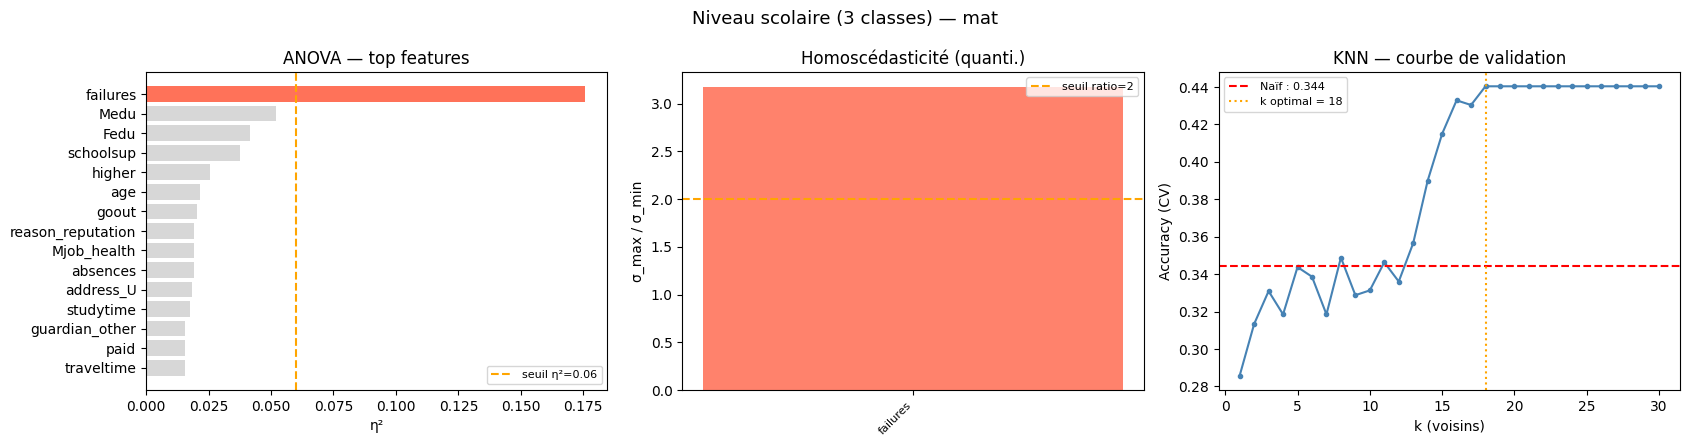

Naïf                  : 0.344
KNN (k=18)         : 0.440
LDA (sans shrinkage)  : 0.385 ± 0.086   [QDA justifié (LDA en violation)]
QDA (sans reg_param)  : 0.410 ± 0.091
Régression logistique : 0.375 ± 0.075


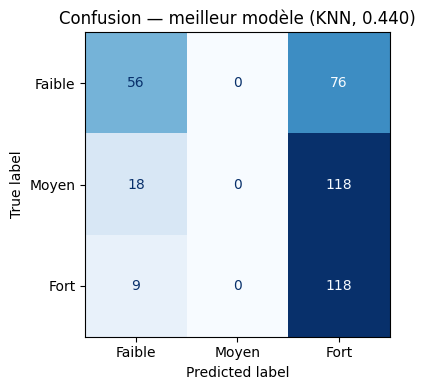

In [5]:
results.append(run_level_analysis(student_mat, dataset_label='mat'))

---
## 6. student-por

=== Niveau scolaire — por (n=649) ===
Répartition : Faible=228, Moyen=208, Fort=213   (naïf = 0.351)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['failures', 'higher', 'school_MS', 'Medu', 'studytime']
Features effectivement utilisées : ['failures', 'higher', 'school_MS', 'Medu', 'studytime']
⚠️  Homoscédasticité violée par ['failures'] (ratio > 2)
   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.
   → On exécute quand même LDA sans shrinkage (comme demandé) pour comparer théorie et pratique.
   Ratios σ_max/σ_min (variables quantitatives) : {'failures': 5.06, 'studytime': 1.1, 'Medu': 1.06}



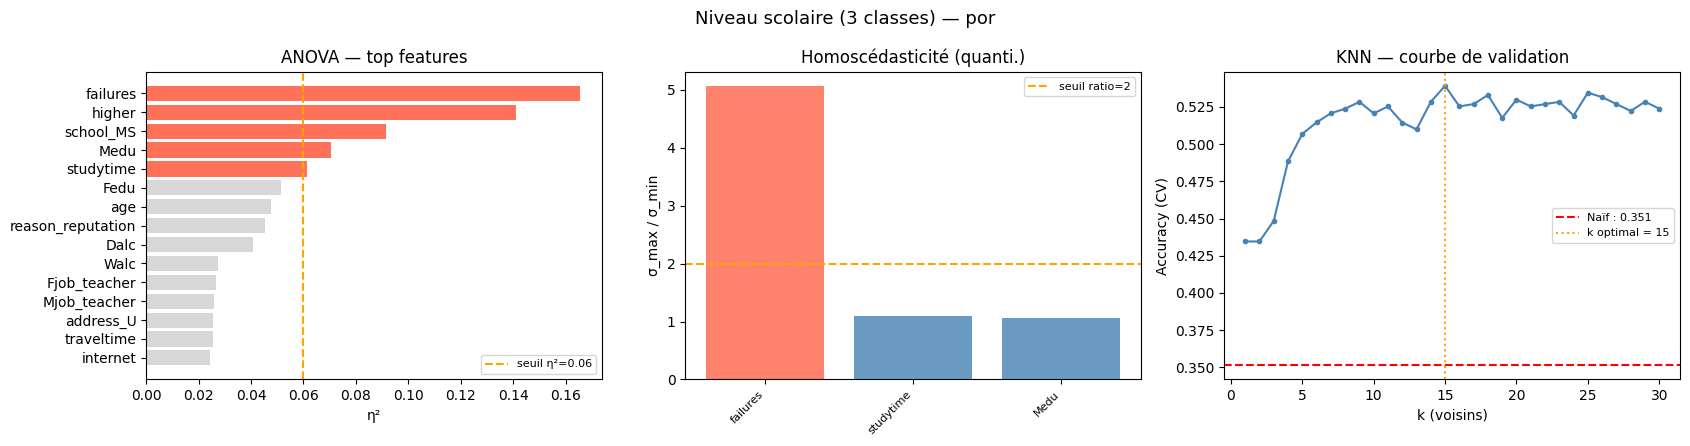

Naïf                  : 0.351
KNN (k=15)         : 0.539
LDA (sans shrinkage)  : 0.539 ± 0.051   [QDA justifié (LDA en violation)]
QDA (sans reg_param)  : 0.502 ± 0.086
Régression logistique : 0.547 ± 0.055


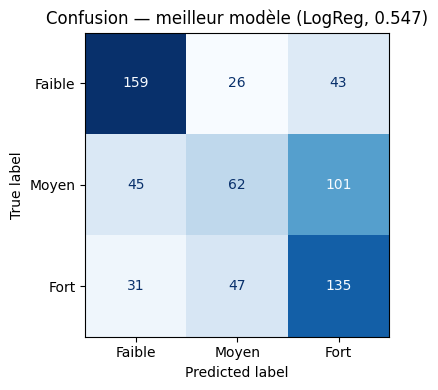

In [6]:
results.append(run_level_analysis(student_por, dataset_label='por'))

---
## 7. Et si on retire `failures` du jeu de variables ?

`failures` est, dans les deux datasets, **à la fois** la variable la plus informative (η² = 0.176 / 0.165)
**et** celle qui viole l'homoscédasticité (ratio σ ≈ 3.2 / 5.1, seuil = 2). Plutôt que de se contenter de
*constater* la violation et de discuter de la robustesse de LDA face à elle (ce qu'on fera en section 8),
testons directement l'hypothèse causale : si on retire purement et simplement `failures` du jeu de
modélisation, deux choses devraient se vérifier en théorie —

1. **l'homoscédasticité doit alors être respectée** sur ce qui reste, confirmant que c'était bien `failures`,
   et seulement elle, qui posait problème ;
2. **le signal disponible doit chuter** — puisqu'on retire la variable la plus discriminante.

(`failures` reste affichée — en orange — dans le graphique ANOVA ci-dessous : on la voit, on choisit
explicitement de l'écarter, on ne la « rate » pas par inadvertance.)

=== Niveau scolaire — mat — sans ['failures'] (écartée) (n=395) ===
Répartition : Faible=132, Moyen=136, Fort=127   (naïf = 0.344)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['failures']
  → écartée volontairement du jeu de modélisation : ['failures']
Features effectivement utilisées : (aucune)

⚠️  Plus aucune variable au-dessus du seuil η² > 0.06 une fois ['failures'] écartée : il ne reste littéralement aucun signal exploitable dans ce jeu de variables — ['failures'] portait, à elle seule, toute la structure prédictive détectée pour ce dataset.

Naïf                  : 0.344   (aucun modèle ne peut faire mieux ici)
=== Niveau scolaire — por — sans ['failures'] (écartée) (n=649) ===
Répartition : Faible=228, Moyen=208, Fort=213   (naïf = 0.351)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['failures', 'higher', 'school_MS', 'Medu', 'studytime']
  → écartée volontairement du jeu de modélisation : ['failures']
Features effectivement utilisées : ['higher', 'school_MS', 'Medu', 

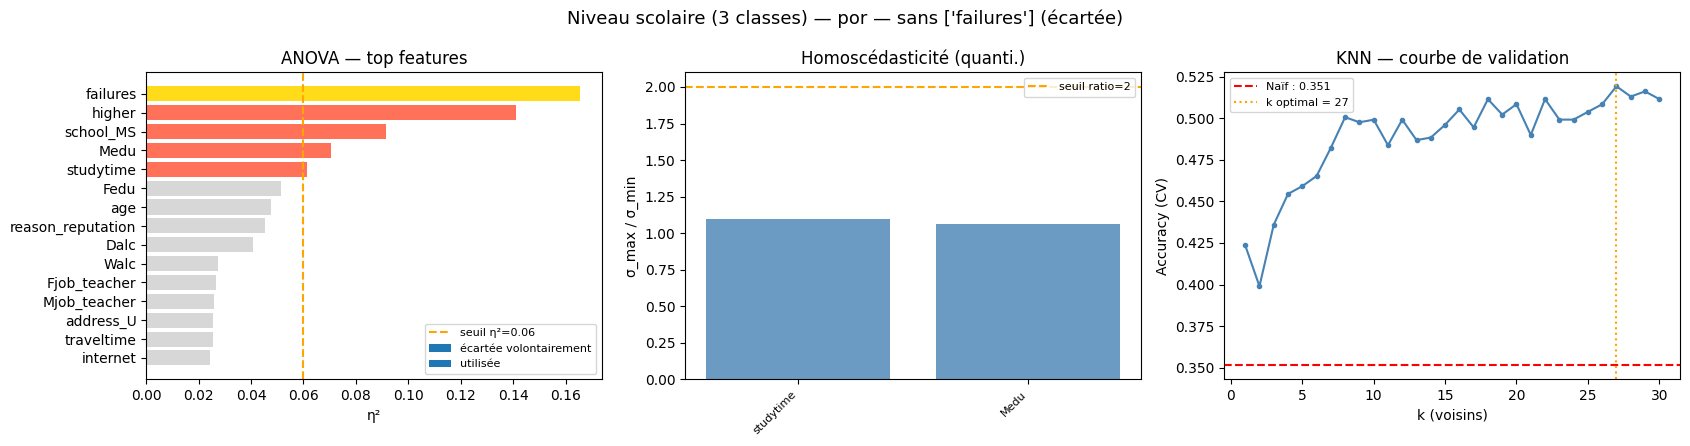

Naïf                  : 0.351
KNN (k=27)         : 0.519
LDA (sans shrinkage)  : 0.515 ± 0.030   [LDA justifié]
QDA (sans reg_param)  : 0.450 ± 0.048
Régression logistique : 0.521 ± 0.032


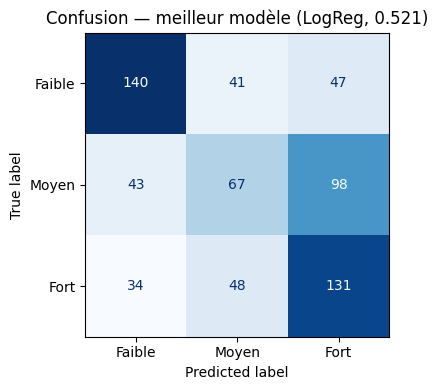

In [7]:
results.append(run_level_analysis(student_mat, dataset_label='mat', exclude_feats=['failures']))
results.append(run_level_analysis(student_por, dataset_label='por', exclude_feats=['failures']))

---
## 8. Théorie vs pratique — ce que révèle la confrontation

Deux expériences, un seul fil conducteur : vérifier les hypothèses ne sert pas qu'à choisir un modèle dans
l'absolu — ça change la confiance qu'on peut accorder à son interprétation, et ça peut même se *corriger*.

**Expérience 1 — tester la robustesse face à la violation (sections 5-6).** `failures` viole
l'homoscédasticité dans les deux datasets (ratio σ ≈ 3.2 sur `mat`, ≈ 5.1 sur `por` — la même variable,
structurellement, que celle déjà repérée comme problématique dans `apprentissage_mat_sur_kmeans`). Sur le
papier, **QDA est donc le choix justifié** : c'est exactement la situation que le test de Box est censé
détecter. En pratique, le match est partagé et serré : QDA (sans régularisation) prend l'avantage sur `mat`
(0.410 contre 0.385 pour LDA), tandis que LDA reprend la main sur `por` (0.539 contre 0.502). Aucun des deux
ne s'impose nettement — et surtout, **LDA, en violation de son hypothèse, ne s'effondre pas du tout** : elle
reste compétitive avec un modèle qui, lui, a la flexibilité théorique « adaptée » à la situation. Un résultat
documenté de la théorie de la décision statistique : **LDA est relativement robuste aux violations modérées
d'homoscédasticité**, surtout avec peu de classes et peu de variables — la flexibilité supplémentaire de QDA
ne se traduit pas mécaniquement par un avantage décisif quand le signal lui-même est limité.

**Expérience 2 — corriger la violation plutôt que la subir (section 7).** La robustesse de LDA est
rassurante, mais elle ne dispense pas de comprendre *pourquoi* l'hypothèse est violée — et, si possible,
d'agir en conséquence. En retirant `failures`, on observe exactement ce que prédit la théorie :
- sur `por`, l'homoscédasticité est alors **respectée** (les ratios tombent à 1.06 et 1.10, bien sous le
  seuil de 2) → LDA devient le choix proprement justifié — et c'est précisément là qu'elle obtient sa
  meilleure performance *relative* : 0.515, à 0.006 du meilleur modèle (régression logistique, 0.521),
  quasiment à égalité, pendant que QDA recule nettement (0.450) faute de pouvoir exploiter sa flexibilité
  sur un signal devenu ténu ;
- sur `mat`, il ne reste **plus aucune variable** au-dessus du seuil η² > 0.06 : `failures` portait, à elle
  seule, toute la structure prédictive détectée pour ce dataset — un résultat presque aussi informatif que
  la performance elle-même.

**Synthèse.** Les deux expériences se complètent plutôt qu'elles ne se contredisent : la première montre
que, quand l'hypothèse est violée, le match LDA/QDA reste serré et dépend du dataset — ni l'un ni l'autre
n'a un avantage systématique, ce qui en soi relativise l'idée que « violer l'hypothèse condamne LDA ». La
seconde va plus loin : en rétablissant les conditions de validité de LDA (en écartant la variable fautive
plutôt qu'en la subissant), LDA cesse d'être à égalité avec QDA pour devenir clairement la meilleure option
*parmi les modèles dont les hypothèses sont respectées* — quasiment au niveau du meilleur modèle toutes
catégories confondues (régression logistique). Le facteur limitant n'a donc jamais été, en soi, le choix
entre LDA et QDA — c'est la rareté du signal une fois les notes écartées (ici, au mieux, 4 variables avec
des η² entre 0.06 et 0.18). Mais vérifier (et, ici, corriger) les hypothèses a changé quelque chose
d'essentiel : sur `por` sans `failures`, on peut désormais lire et interpréter LDA en sachant que ses
conditions de validité sont réunies — ce qui n'était pas le cas avant, et qui n'est pas un détail technique,
mais la différence entre une estimation et une estimation *fiable*.

---
## 9. Et si on incluait G1 et G2 ? — la même démonstration de circularité

Comme dans la version précédente, on vérifie ce que devient la performance si on réintroduit G1 et G2 dans
les features (toujours sans G3, qui serait une fuite directe trop extrême). On s'attend à un bond massif —
pas parce que les modèles auraient soudain « compris » le profil des élèves, mais parce que G1 et G2 *sont*
des notes (corrélation ≈ 0.8-0.9 avec G3, donc avec la moyenne qui définit la cible).

=== Niveau scolaire — mat — avec G1/G2 (comparaison) (n=395) ===
Répartition : Faible=132, Moyen=136, Fort=127   (naïf = 0.344)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['G1', 'G2', 'failures']
Features effectivement utilisées : ['G1', 'G2', 'failures']
⚠️  Homoscédasticité violée par ['failures', 'G2'] (ratio > 2)
   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.
   → On exécute quand même LDA sans shrinkage (comme demandé) pour comparer théorie et pratique.
   Ratios σ_max/σ_min (variables quantitatives) : {'failures': 3.17, 'G2': 2.22, 'G1': 1.27}



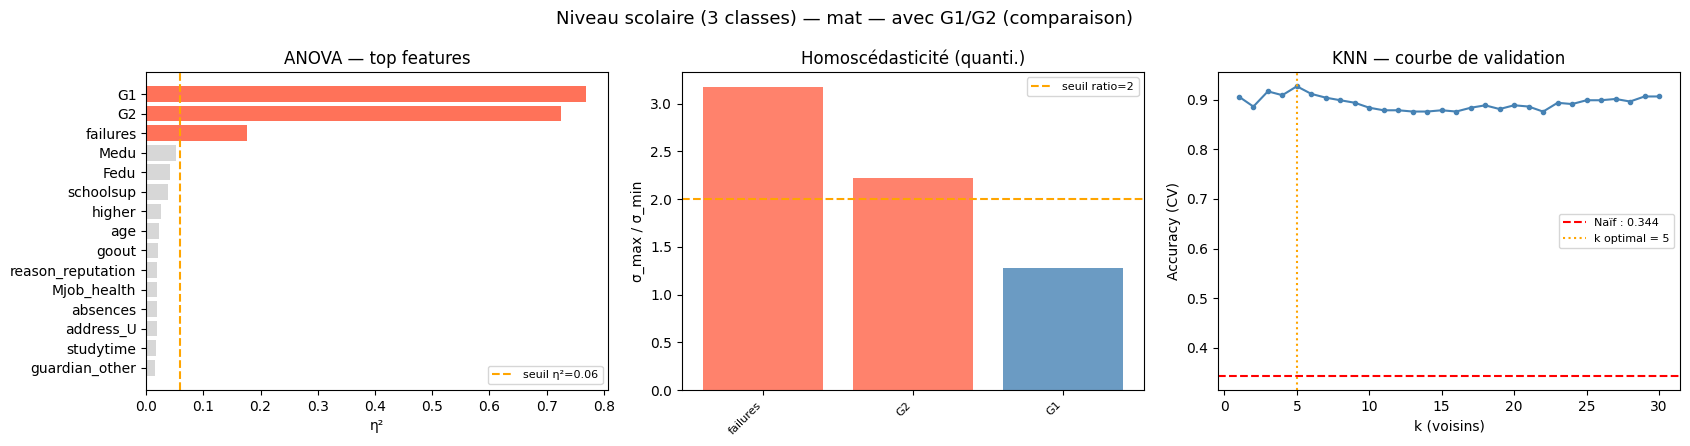

Naïf                  : 0.344
KNN (k= 5)         : 0.927
LDA (sans shrinkage)  : 0.904 ± 0.055   [QDA justifié (LDA en violation)]
QDA (sans reg_param)  : 0.886 ± 0.034
Régression logistique : 0.914 ± 0.044


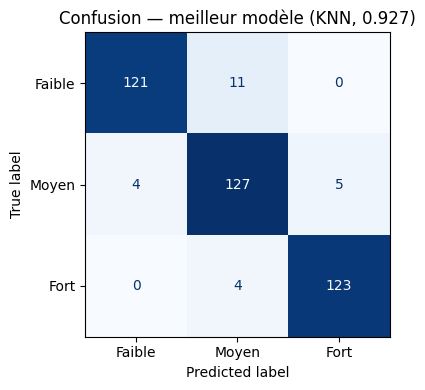

=== Niveau scolaire — por — avec G1/G2 (comparaison) (n=649) ===
Répartition : Faible=228, Moyen=208, Fort=213   (naïf = 0.351)
Features sélectionnées par l'ANOVA (η² > 0.06) : ['G1', 'G2', 'failures', 'higher', 'school_MS', 'Medu', 'studytime']
Features effectivement utilisées : ['G1', 'G2', 'failures', 'higher', 'school_MS', 'Medu', 'studytime']
⚠️  Homoscédasticité violée par ['failures', 'G2'] (ratio > 2)
   → Par la logique du test de Box (TP09), QDA serait le choix théoriquement justifié ici.
   → On exécute quand même LDA sans shrinkage (comme demandé) pour comparer théorie et pratique.
   Ratios σ_max/σ_min (variables quantitatives) : {'failures': 5.06, 'G2': 2.44, 'G1': 1.58, 'studytime': 1.1, 'Medu': 1.06}



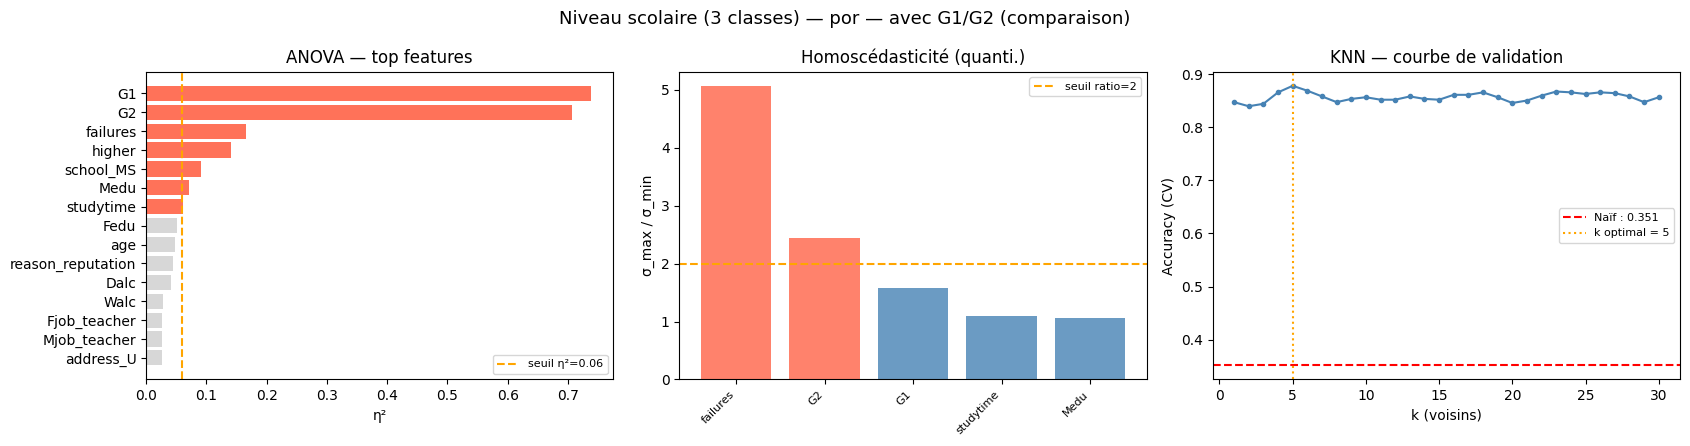

Naïf                  : 0.351
KNN (k= 5)         : 0.878
LDA (sans shrinkage)  : 0.881 ± 0.042   [QDA justifié (LDA en violation)]
QDA (sans reg_param)  : 0.852 ± 0.033
Régression logistique : 0.949 ± 0.024


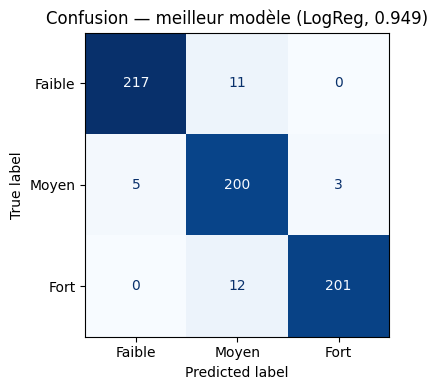


=== Comparaison sans / avec G1, G2 ===
mat : sans notes = 0.440   |   avec G1/G2 = 0.927   (bond de +0.486)
por : sans notes = 0.547   |   avec G1/G2 = 0.949   (bond de +0.402)


In [8]:
results.append(run_level_analysis(student_mat, dataset_label='mat', include_grades=True))
results.append(run_level_analysis(student_por, dataset_label='por', include_grades=True))

print("\n=== Comparaison sans / avec G1, G2 ===")
for name in ['mat', 'por']:
    sans = next(r for r in results if r['dataset'] == name and not r['avec_notes'])
    avec = next(r for r in results if r['dataset'] == name and r['avec_notes'])
    best_sans = max(sans[m] for m in ['KNN', 'LDA', 'QDA', 'LogReg'])
    best_avec = max(avec[m] for m in ['KNN', 'LDA', 'QDA', 'LogReg'])
    print(f"{name} : sans notes = {best_sans:.3f}   |   avec G1/G2 = {best_avec:.3f}   "
          f"(bond de {best_avec - best_sans:+.3f})")

## Conclusion

### Le passage à 3 classes équilibrées change le diagnostic, pas le verdict

| Dataset | Naïf | Meilleur modèle (sans notes) | Gain |
|---|---|---|---|
| `mat` | 34.4% | **44.0%** (KNN, k=18) | **+9.6 pts** |
| `por` | 35.1% | **54.7%** (Régression logistique) | **+19.6 pts** |

Avec des classes équilibrées (~1/3 chacune), le modèle naïf retombe à sa vraie valeur de référence — et
l'écart qu'on observe est donc un gain *réel*, pas gonflé par un déséquilibre de classes. Sur `por`
notamment, le gain de +19.6 points est net : situer un élève dans le bon tiers de niveau, sans avoir vu la
moindre note, fonctionne sensiblement mieux que deviner au hasard.

### Les variables qui portent ce signal — toujours les mêmes

| Feature | η² (mat) | η² (por) |
|---|---|---|
| `failures` (redoublements antérieurs) | **0.176** | **0.165** |
| `higher` (veut poursuivre des études sup.) | — | 0.141 |
| `school_MS` (établissement) | — | 0.091 |
| `Medu` (éducation de la mère) | 0.052 | 0.070 |
| `studytime` | — | 0.062 |

Sans surprise — et c'est rassurant méthodologiquement — on retrouve exactement la même hiérarchie que dans
la version binaire : `failures` domine très largement, suivie par l'ambition (`higher`) et le capital
parental (`Medu`/`Fedu`). Le passage à 3 classes ne change pas *quelles* variables comptent, seulement la
*résolution* avec laquelle on peut situer un élève.

### Vérifier les hypothèses a changé l'angle d'analyse — sans changer le résultat final

En appliquant la logique du test de Box (sections 7-8), on a établi que `failures` viole systématiquement
l'homoscédasticité (ratio σ ≈ 3.2 / 5.1 — la même variable, le même phénomène structurel que celui déjà
identifié sur les clusters K-means) — désignant **QDA comme le modèle théoriquement justifié**. En
pratique pourtant, le match LDA/QDA reste serré et dépend du dataset (QDA gagne sur `mat`, LDA sur `por`) :
LDA, en violation de son hypothèse, ne s'effondre absolument pas, ce qui illustre sa robustesse connue aux
violations modérées. Mais on est allé plus loin qu'un simple constat : en
**retirant `failures`** (section 7), on a vérifié — et confirmé — que c'était bien elle, et seulement elle,
qui posait problème : sur `por`, l'homoscédasticité devient respectée (ratios ≈ 1.06-1.10), LDA y devient
alors clairement la meilleure option *parmi les modèles dont les hypothèses sont respectées* — et obtient
une performance quasi à égalité avec le meilleur modèle toutes catégories confondues (0.515 contre 0.521
pour la régression logistique). Sur `mat`, il ne reste alors plus aucun signal exploitable — `failures` portait, à
elle seule, toute la structure prédictive du dataset. Le facteur limitant reste **la rareté du signal**
(au mieux 4-5 variables, η² entre 0.05 et 0.18) — mais vérifier *et corriger* les hypothèses a changé la
confiance qu'on peut accorder à l'interprétation du modèle retenu, ce qui n'est pas un détail accessoire.

### Et si on regarde quand même les notes ? — la frontière entre « prédire » et « constater » (inchangée)

Réintroduire G1/G2 fait toujours s'envoler la performance (de 84.6% à 94.9% selon le modèle et le
dataset, voir section 9) — confirmant, à 3
classes comme à 2, que ce bond ne mesure rien d'autre que la corrélation mécanique entre les notes
elles-mêmes. La vraie question — peut-on situer un élève *avant* tout examen — reste celle des sections 5-6,
et la réponse reste la même : oui, dans une mesure modeste mais désormais clairement quantifiée et
honnêtement contextualisée par la vérification de ses propres conditions de validité.